# Notebook reprenant le pipeline de l'article Windowed Radon Transform & Tensor Rank-1 Decomposition for Adaptive Beamforming in Ultrafast Ultrasound

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from scipy.signal.windows import tukey
from skimage.transform import radon
from scipy.fft import fft, ifft, fftfreq

from skimage.transform import iradon
import scipy.ndimage as ndimage

## ÉTAPE 1 : Génération des données CRF (Complex Radio-Frequency)


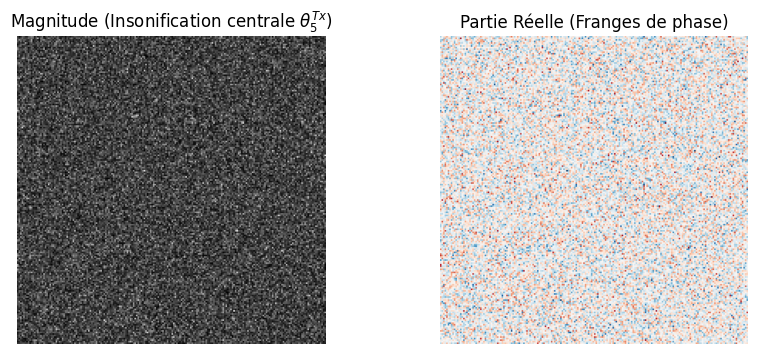

In [2]:
# Paramètres basés sur l'article (simplifiés pour le test)
n_tx = 9          # Nombre d'insonifications (ondes planes)
nz, nx = 200, 200 # Taille de la grille spatiale
f0 = 0.08         # Fréquence spatiale porteuse (pour simuler le signal analytique)

# Création de la structure cible (Réflectivité du tissu)
base_env = np.zeros((nz, nx))
for i in range(nx):
    z_val = int(100 + 40 * np.sin(i / 35.0))
    if 0 <= z_val < nz: 
        base_env[z_val, i] = 1.0
base_env = gaussian_filter(base_env, sigma=1.5)

Z, X = np.indices((nz, nx))
carrier = np.exp(1j * 2 * np.pi * f0 * Z)
complex_base = base_env * carrier

np.random.seed(42)
y_das_series = []

for _ in range(n_tx):
    # Bruit complexe (aberration de phase + speckle)
    noise = np.random.normal(0, 0.4, (nz, nx)) + 1j * np.random.normal(0, 0.4, (nz, nx))
    y_das_series.append(complex_base + noise)

y_das_series = np.array(y_das_series)

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(y_das_series[4]), cmap='gray')
axes[0].set_title(r"Magnitude (Insonification centrale $\theta^{Tx}_5$)")
axes[1].imshow(np.real(y_das_series[4]), cmap='RdBu')
axes[1].set_title(r"Partie Réelle (Franges de phase)")
for ax in axes: ax.axis('off')
plt.show()

## ÉTAPE 2 : Angles, Fenêtrage et Transformée de Radon

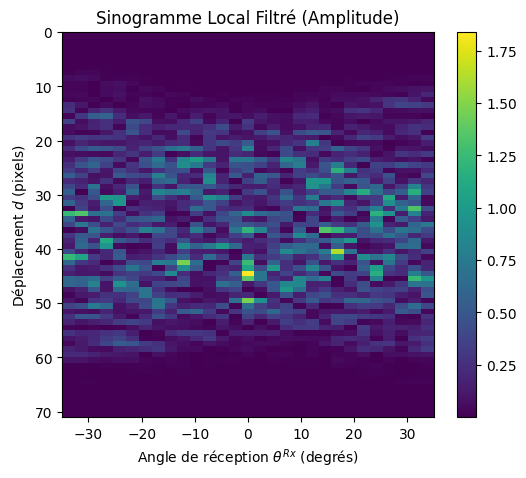

In [3]:
# Définition des angles selon l'article
theta_tx = np.linspace(-20, 20, 9)     # 9 angles Tx
theta_rx = np.arange(-35, 35.1, 2.5)   # Angles Rx (espacement < 3.82°)

# Ajustement pour skimage : 0° en physique (onde plane de haut en bas) 
# correspond souvent à une rotation de 90° dans la projection radon classique.
angles_skimage = theta_rx + 90 

# 2. Paramètres de la fenêtre locale (Tukey 0.5)
win_size = 50 # On prend 50x50 pixels pour l'exemple
w_1d = tukey(win_size, alpha=0.5)
w_2d = np.outer(w_1d, w_1d) # Fenêtre 2D

# 3. Fonction de filtrage (Ram-Lak) selon l'Équation 18
def filter_sinogram(sino):
    """
    Applique le filtre ram-lak |zeta| dans le domaine fréquentiel 
    sur la dimension des distances 'd'.
    """
    n_d, n_angles = sino.shape
    freqs = fftfreq(n_d)
    ram_lak = np.abs(freqs) # Filtre en V
    
    # Passage en Fourier (1D sur l'axe des distances d)
    sino_fft = fft(sino, axis=0)
    sino_filtered_fft = sino_fft * ram_lak[:, np.newaxis]
    
    return np.real(ifft(sino_filtered_fft, axis=0))

# 4. Extraction d'un patch central pour le test
z_start, x_start = 75, 75
patch_tx_series = y_das_series[:, z_start:z_start+win_size, x_start:x_start+win_size]

# 5. Transformée de Radon fenêtrée
sinograms_filtered = []

# On boucle sur chaque insonification Tx
for i_tx in range(n_tx):
    patch = patch_tx_series[i_tx] * w_2d
    
    # scikit-image gère les réels, on sépare partie réelle et imaginaire
    sino_real = radon(np.real(patch), theta=angles_skimage, circle=False)
    sino_imag = radon(np.imag(patch), theta=angles_skimage, circle=False)
    
    # Recombinaison complexe
    sino_complex = sino_real + 1j * sino_imag
    
    # Application du filtre
    sino_filt = filter_sinogram(sino_complex)
    sinograms_filtered.append(sino_filt)

# Tensor des sinogrammes locaux : shape (9, N_d, 29) -> (Tx, d, Rx)
sinograms_filtered = np.array(sinograms_filtered)

# --- Affichage du sinogramme ---
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
# Affichage de l'amplitude du sinogramme filtré pour l'onde plane centrale
im = ax.imshow(np.abs(sinograms_filtered[4]), aspect='auto', 
               extent=[theta_rx[0], theta_rx[-1], sinograms_filtered.shape[1], 0],
               cmap='viridis')
ax.set_title("Sinogramme Local Filtré (Amplitude)")
ax.set_xlabel(r"Angle de réception $\theta^{Rx}$ (degrés)")
ax.set_ylabel("Déplacement $d$ (pixels)")
plt.colorbar(im, ax=ax)
plt.show()

## ÉTAPE 3 : Décomposition Tensorielle Rang-1 (ALS) - Algorithme 1

In [4]:
# On transpose notre tenseur pour avoir la forme (Tx, Rx, d)
s_patch = np.transpose(sinograms_filtered, (0, 2, 1))
n_tx, n_rx, n_d = s_patch.shape

# 1. Préparation de la géométrie de l'angle "mid"
# theta_mid = (theta_tx + theta_rx) / 2
theta_tx_grid, theta_rx_grid = np.meshgrid(theta_tx, theta_rx, indexing='ij')
theta_mid_matrix = (theta_tx_grid + theta_rx_grid) / 2

# On identifie tous les angles "mid" uniques pour éviter l'interpolation
theta_mid_unique, mid_idx_matrix = np.unique(theta_mid_matrix, return_inverse=True)
mid_idx_matrix = mid_idx_matrix.reshape(n_tx, n_rx)
n_mid = len(theta_mid_unique)

# 2. Paramètres de l'ALS selon l'article
mu = 1.0          # Paramètre de régularisation par défaut
n_iter = 20       # Nombre d'itérations recommandées

# Initialisation
l_tx = np.ones(n_tx, dtype=np.complex128)
l_rx = np.ones(n_rx, dtype=np.complex128)
f_mid = np.zeros((n_mid, n_d), dtype=np.complex128)

print("Début de l'ALS (Algorithme 1)...")
for iteration in range(n_iter):
    norm_tx_sq = np.sum(np.abs(l_tx)**2)
    norm_rx_sq = np.sum(np.abs(l_rx)**2)

    # --- A. Mise à jour de f(mid, d) ---
    num_f = np.zeros((n_mid, n_d), dtype=np.complex128)
    den_f = np.zeros(n_mid, dtype=np.float64)

    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            # Produit des tenseurs d'aberration conjugués
            weight = np.conj(l_tx[i_tx]) * np.conj(l_rx[i_rx])
            num_f[m_idx, :] += weight * s_patch[i_tx, i_rx, :]
            den_f[m_idx] += np.abs(l_tx[i_tx] * l_rx[i_rx])**2

    # Ajout du terme de régularisation
    den_f += mu * norm_tx_sq * norm_rx_sq
    f_mid = num_f / den_f[:, None]
    
    norm_f_sq = np.sum(np.abs(f_mid)**2)

    # --- B. Mise à jour de l_rx ---
    num_rx = np.zeros(n_rx, dtype=np.complex128)
    den_rx = np.zeros(n_rx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            weight = np.conj(l_tx[i_tx]) * np.conj(f_mid[m_idx, :])
            num_rx[i_rx] += np.sum(weight * s_patch[i_tx, i_rx, :])
            den_rx[i_rx] += np.abs(l_tx[i_tx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
            
    den_rx += mu * norm_tx_sq * norm_f_sq
    l_rx = num_rx / den_rx
    norm_rx_sq = np.sum(np.abs(l_rx)**2)

    # --- C. Mise à jour de l_tx ---
    num_tx = np.zeros(n_tx, dtype=np.complex128)
    den_tx = np.zeros(n_tx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            weight = np.conj(l_rx[i_rx]) * np.conj(f_mid[m_idx, :])
            num_tx[i_tx] += np.sum(weight * s_patch[i_tx, i_rx, :])
            den_tx[i_tx] += np.abs(l_rx[i_rx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
            
    den_tx += mu * norm_rx_sq * norm_f_sq
    l_tx = num_tx / den_tx

# 3. Normalisation finale selon l'Algorithme 1
n_tx_norm = np.sqrt(np.sum(np.abs(l_tx)**2))
n_rx_norm = np.sqrt(np.sum(np.abs(l_rx)**2))

l_tx = l_tx / n_tx_norm
l_rx = l_rx / n_rx_norm
f_mid = f_mid * (n_tx_norm * n_rx_norm)

print("ALS terminé. Dimensions de f_mid :", f_mid.shape)

Début de l'ALS (Algorithme 1)...
ALS terminé. Dimensions de f_mid : (45, 71)


## ÉTAPE 4 : Rétroprojection et Algorithme 2 (Overlap-Add + Correction de Phase)

1. Rétroprojection et initialisation de l'image globale...
2. Alignement itératif des phases...


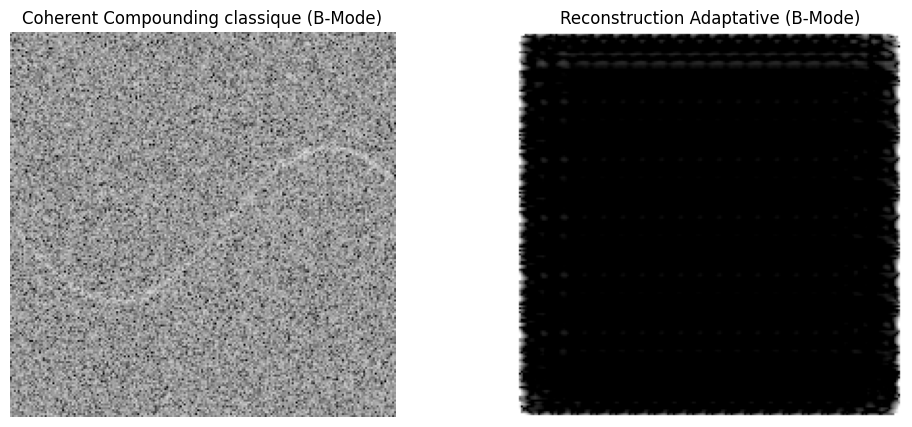

In [5]:
step = 10 # Pas de glissement de la fenêtre (doit assurer un bon recouvrement)
n_iter_out = 10 # Nombre d'itérations pour la correction de phase selon l'article

# 1. Préparation des toiles pour l'image finale
output_image_f = np.zeros((nz, nx), dtype=np.complex128)
norm_map = np.zeros((nz, nx), dtype=np.float64)

# Structure pour stocker nos patchs reconstruits et fenêtrés
# (Nécessaire pour l'itération de phase de l'Algo 2)
patches_dict = {}

print("1. Rétroprojection et initialisation de l'image globale...")
for z in range(0, nz - win_size + 1, step):
    for x in range(0, nx - win_size + 1, step):
        
        # Note : Dans le pipeline complet, c'est ici qu'on appelle l'ALS (Étape 3)
        # Pour l'exemple, supposons que f_mid est le résultat de l'ALS pour ce (z, x).
        # On va utiliser le f_mid qu'on a calculé à l'étape précédente.
        
        # Rétroprojection (iRadon) : Skimage attend (d, angles), donc on transpose f_mid
        # Skimage ne gère pas les complexes, on sépare :
        patch_rec_real = iradon(np.real(f_mid).T, theta=theta_mid_unique + 90, circle=False, output_size=win_size)
        patch_rec_imag = iradon(np.imag(f_mid).T, theta=theta_mid_unique + 90, circle=False, output_size=win_size)
        
        patch_rec_complex = patch_rec_real + 1j * patch_rec_imag
        
        # Fenêtrage du patch reconstruit
        y_f_w = patch_rec_complex * w_2d
        
        # Stockage du patch
        patches_dict[(z, x)] = y_f_w
        
        # Ajout à l'image globale (initialisation)
        output_image_f[z:z+win_size, x:x+win_size] += y_f_w
        norm_map[z:z+win_size, x:x+win_size] += (w_2d ** 2)

# 2. Correction Itérative de Phase (L'essence de l'Algorithme 2)
print("2. Alignement itératif des phases...")
for i_out in range(n_iter_out):
    for (z, x), y_f_w in patches_dict.items():
        
        # Soustraire le patch actuel de l'image globale
        y_f_0 = output_image_f[z:z+win_size, x:x+win_size] - y_f_w
        
        # Calcul du déphasage "v" entre le reste de l'image et ce patch
        v = np.sum(y_f_0 * np.conj(y_f_w))
        
        if np.abs(v) > 0: # Sécurité division par zéro
            # Correction de la phase du patch
            y_f_w_corrected = (v / np.abs(v)) * y_f_w
            patches_dict[(z, x)] = y_f_w_corrected
            
            # Mise à jour locale de l'image globale (ajouter le nouveau patch corrigé)
            output_image_f[z:z+win_size, x:x+win_size] += y_f_w_corrected

# 3. Recomposition finale et normalisation
output_image_f = np.zeros((nz, nx), dtype=np.complex128)
for (z, x), y_f_w in patches_dict.items():
    output_image_f[z:z+win_size, x:x+win_size] += y_f_w

# Division par la carte de normalisation pour lisser les recouvrements
mask = norm_map > 1e-5
output_image_f[mask] /= norm_map[mask]

# 4. Conversion en Mode-B (Log-Compressé)
b_mode_image = np.zeros((nz, nx))
b_mode_image[mask] = 20 * np.log10(np.abs(output_image_f[mask]) + 1e-12)

# --- Affichage Final ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Image d'origine (moyenne basique cohérente type compounding)
base_compounding = np.mean(y_das_series, axis=0)
im1 = axes[0].imshow(20 * np.log10(np.abs(base_compounding) + 1e-12), cmap='gray', vmin=-40, vmax=0)
axes[0].set_title("Coherent Compounding classique (B-Mode)")

# Image corrigée
im2 = axes[1].imshow(b_mode_image, cmap='gray', vmin=-40, vmax=0)
axes[1].set_title("Reconstruction Adaptative (B-Mode)")

for ax in axes: ax.axis('off')
plt.show()

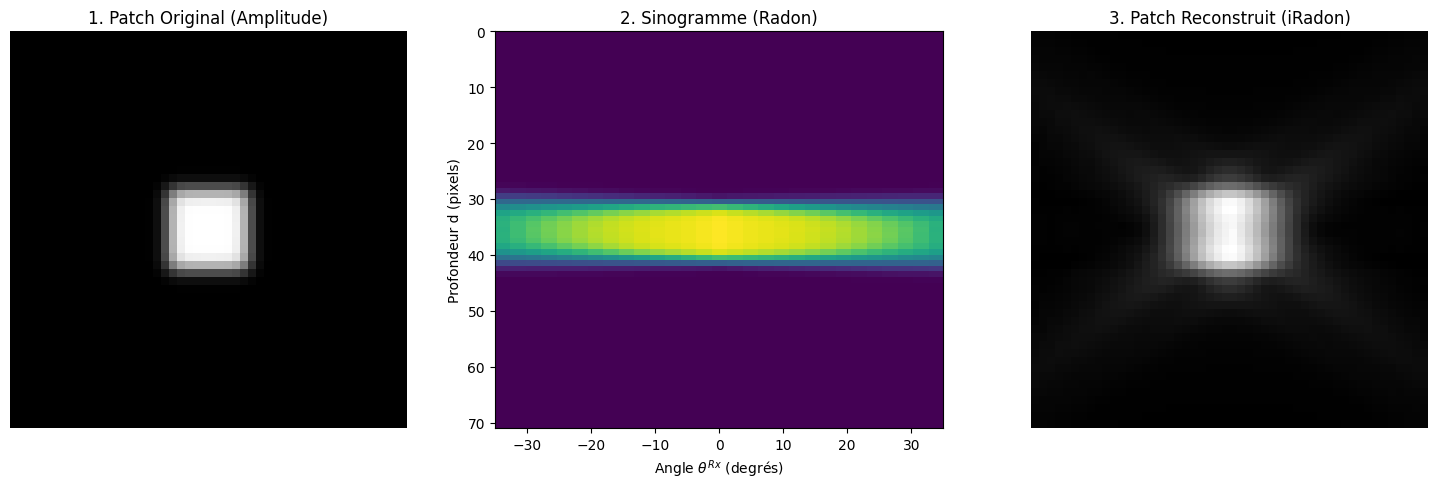

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import tukey
from skimage.transform import radon, iradon

# ==========================================
# ÉTAPE 1 : Test de la géométrie Radon (Unitaire)
# Objectif : Vérifier que l'aller-retour Radon/iRadon fonctionne 
# et que les axes (le +90°) respectent l'onde ultrasonore.
# ==========================================

# 1. Création d'un patch cible simple (un point brillant)
win_size = 50
f0 = 0.08
Z, X = np.indices((win_size, win_size))
carrier = np.exp(1j * 2 * np.pi * f0 * Z) # Onde se propageant en Z (profondeur)

patch_base = np.zeros((win_size, win_size))
patch_base[20:30, 20:30] = 1.0 # Cible au centre
patch_base = gaussian_filter(patch_base, sigma=1.0)

# Application de la porteuse (signal analytique) et de la fenêtre
w_1d = tukey(win_size, alpha=0.5)
w_2d = np.outer(w_1d, w_1d)
patch = patch_base * carrier * w_2d

# 2. Transformée de Radon
theta_rx = np.arange(-35, 35.1, 2.5)

# On teste notre hypothèse du +90° pour aligner l'axe de profondeur
angles_skimage = theta_rx + 90 

s_real = radon(np.real(patch), theta=angles_skimage, circle=False)
s_imag = radon(np.imag(patch), theta=angles_skimage, circle=False)
sino_complex = s_real + 1j * s_imag

# 3. Rétroprojection (iRadon)
# Si l'opération est parfaite, on doit retrouver le patch complexe d'origine
rec_real = iradon(s_real, theta=angles_skimage, circle=False, output_size=win_size)
rec_imag = iradon(s_imag, theta=angles_skimage, circle=False, output_size=win_size)
patch_rec = rec_real + 1j * rec_imag

# --- AFFICHAGE ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.abs(patch), cmap='gray')
axes[0].set_title("1. Patch Original (Amplitude)")

axes[1].imshow(np.abs(sino_complex), aspect='auto', cmap='viridis', 
               extent=[theta_rx[0], theta_rx[-1], sino_complex.shape[0], 0])
axes[1].set_title("2. Sinogramme (Radon)")
axes[1].set_xlabel(r"Angle $\theta^{Rx}$ (degrés)")
axes[1].set_ylabel("Profondeur d (pixels)")

axes[2].imshow(np.abs(patch_rec), cmap='gray')
axes[2].set_title("3. Patch Reconstruit (iRadon)")

for ax in [axes[0], axes[2]]:
    ax.axis('off')

plt.tight_layout()
plt.show()

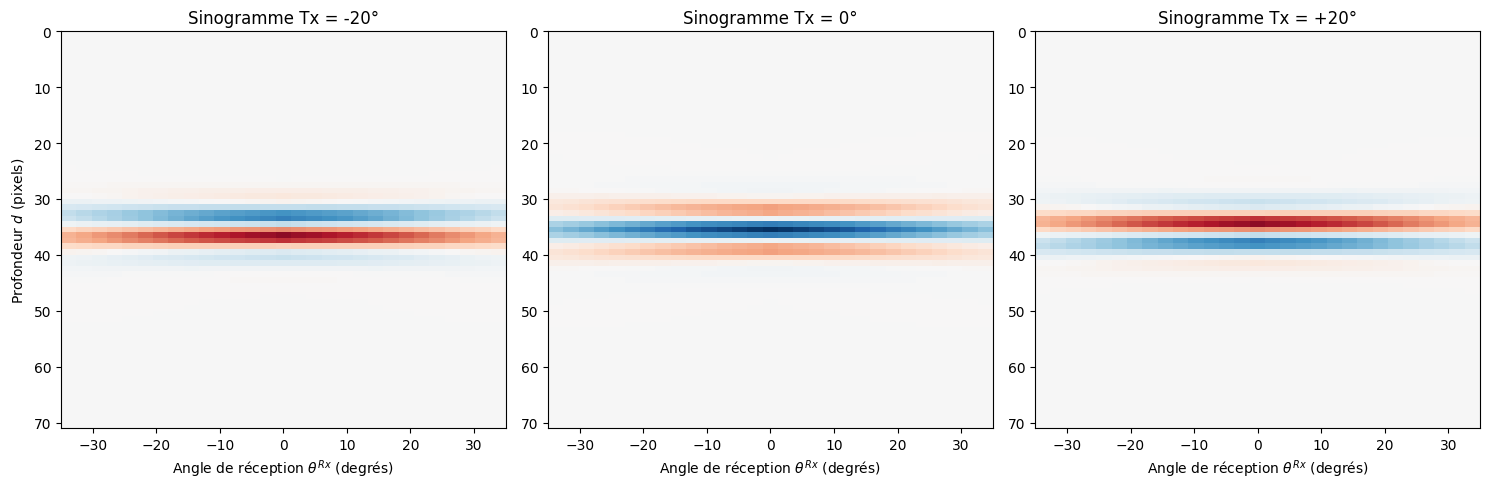

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import tukey
from skimage.transform import radon

# ==========================================
# ÉTAPE 2 : Construction du Tenseur Local s(Tx, Rx, d)
# Objectif : Appliquer Radon sur un patch pour TOUTES les ondes planes (Tx)
# et observer l'effet de l'aberration sur les sinogrammes.
# ==========================================

n_tx = 9
nz, nx = 200, 200
# FIX 1 : On augmente un peu la fréquence pour avoir de belles franges bien visibles
f0 = 0.12 
theta_tx = np.linspace(-20, 20, n_tx)

# 1. Simulation d'une cible simple (Un point brillant au centre)
tissue = np.zeros((nz, nx))
tissue[100, 100] = 10.0 
# FIX 2 : On agrandit la taille de la cible pour qu'elle contienne plusieurs oscillations (cycles)
tissue = gaussian_filter(tissue, sigma=3.0)

Z, X = np.indices((nz, nx))
carrier = np.exp(1j * 2 * np.pi * f0 * Z)

y_das_series = []
for angle in theta_tx:
    # FIX 3 : On crée une aberration déterministe et très forte pour le test.
    # Le retard (en pixels) varie linéairement avec l'angle de tir.
    delay_pixels = 8.0 * np.sin(np.deg2rad(angle)) 
    aberration = np.exp(1j * 2 * np.pi * f0 * delay_pixels)
    
    # Signal = Tissu * Aberration * Porteuse
    signal = tissue * aberration * carrier
    y_das_series.append(signal)
    
y_das_series = np.array(y_das_series)

# 2. Extraction du patch central
win_size = 50
w_1d = tukey(win_size, alpha=0.5)
w_2d = np.outer(w_1d, w_1d)

z_start, x_start = 75, 75
patch_series = y_das_series[:, z_start:z_start+win_size, x_start:x_start+win_size] * w_2d

# 3. Transformée de Radon pour chaque angle Tx
theta_rx = np.arange(-35, 35.1, 2.5)
angles_skimage = theta_rx + 90 

s_patch = []
for i_tx in range(n_tx):
    patch = patch_series[i_tx]
    s_real = radon(np.real(patch), theta=angles_skimage, circle=False)
    s_imag = radon(np.imag(patch), theta=angles_skimage, circle=False)
    s_patch.append(s_real + 1j * s_imag)

# On transpose pour avoir le format exact de l'article : (Tx, Rx, d)
s_patch = np.array(s_patch).transpose((0, 2, 1)) 

# --- AFFICHAGE ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
tx_indices = [0, 4, 8] # Angles d'émission : -20°, 0°, +20°
tx_labels = ["-20°", "0°", "+20°"]

for i, ax in enumerate(axes):
    idx = tx_indices[i]
    vmax = np.max(np.abs(s_patch[idx]))
    
    # FIX 4 : On transpose s_patch[idx] (qui est [Rx, d]) en [d, Rx] 
    # pour que la Profondeur (d) soit bien sur l'axe Y vertical !
    ax.imshow(np.real(s_patch[idx]).T, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax,
              extent=[theta_rx[0], theta_rx[-1], s_patch.shape[2], 0])
    ax.set_title(f"Sinogramme Tx = {tx_labels[i]}")
    ax.set_xlabel(r"Angle de réception $\theta^{Rx}$ (degrés)")
    if i == 0:
        ax.set_ylabel("Profondeur $d$ (pixels)")

plt.tight_layout()
plt.show()

Début de l'ALS (Extraction du signal corrigé)...
ALS terminé.


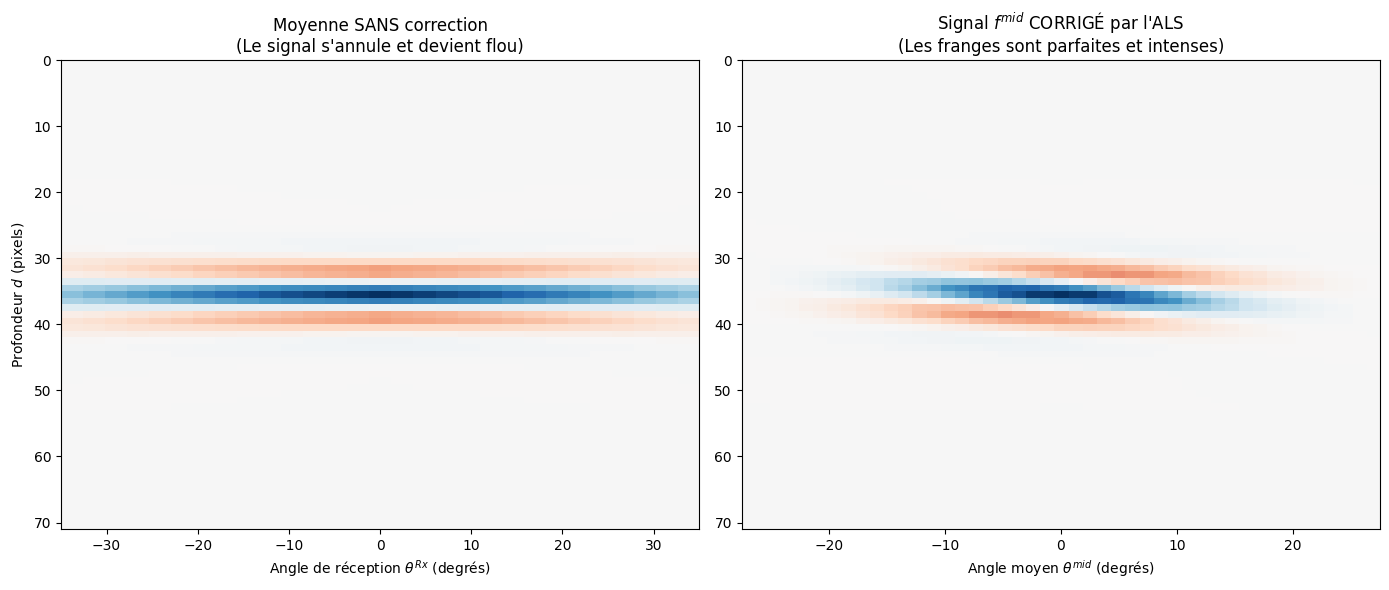

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import tukey
from skimage.transform import radon

# ==========================================
# 1. GÉNÉRATION DES DONNÉES (Identique à l'Étape 2)
# ==========================================
n_tx = 9
nz, nx = 200, 200
f0 = 0.12 
theta_tx = np.linspace(-20, 20, n_tx)

tissue = np.zeros((nz, nx))
tissue[100, 100] = 10.0 
tissue = gaussian_filter(tissue, sigma=3.0)

Z, X = np.indices((nz, nx))
carrier = np.exp(1j * 2 * np.pi * f0 * Z)

y_das_series = []
for angle in theta_tx:
    delay_pixels = 8.0 * np.sin(np.deg2rad(angle)) 
    aberration = np.exp(1j * 2 * np.pi * f0 * delay_pixels)
    signal = tissue * aberration * carrier
    y_das_series.append(signal)
    
y_das_series = np.array(y_das_series)

win_size = 50
w_1d = tukey(win_size, alpha=0.5)
w_2d = np.outer(w_1d, w_1d)

z_start, x_start = 75, 75
patch_series = y_das_series[:, z_start:z_start+win_size, x_start:x_start+win_size] * w_2d

theta_rx = np.arange(-35, 35.1, 2.5)
angles_skimage = theta_rx + 90 
n_rx = len(theta_rx)

s_patch = []
for i_tx in range(n_tx):
    patch = patch_series[i_tx]
    s_real = radon(np.real(patch), theta=angles_skimage, circle=False)
    s_imag = radon(np.imag(patch), theta=angles_skimage, circle=False)
    s_patch.append(s_real + 1j * s_imag)

s_patch = np.array(s_patch).transpose((0, 2, 1)) 
n_d = s_patch.shape[2]

# ==========================================
# ÉTAPE 3 : Décomposition Tensorielle ALS (Algorithme 1)
# Objectif : Isoler les aberrations et extraire le signal pur f_mid
# ==========================================

# 1. Préparation géométrie mid-angle
theta_tx_grid, theta_rx_grid = np.meshgrid(theta_tx, theta_rx, indexing='ij')
theta_mid_matrix = (theta_tx_grid + theta_rx_grid) / 2
theta_mid_unique, mid_idx_matrix = np.unique(theta_mid_matrix, return_inverse=True)
mid_idx_matrix = mid_idx_matrix.reshape(n_tx, n_rx)
n_mid = len(theta_mid_unique)

mu = 1.0 
l_tx = np.ones(n_tx, dtype=np.complex128)
l_rx = np.ones(n_rx, dtype=np.complex128)
f_mid = np.zeros((n_mid, n_d), dtype=np.complex128)

print("Début de l'ALS (Extraction du signal corrigé)...")
for _ in range(15):
    norm_tx_sq, norm_rx_sq = np.sum(np.abs(l_tx)**2), np.sum(np.abs(l_rx)**2)
    
    # Update f_mid
    num_f = np.zeros((n_mid, n_d), dtype=np.complex128)
    den_f = np.zeros(n_mid, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            weight = np.conj(l_tx[i_tx]) * np.conj(l_rx[i_rx])
            num_f[m_idx, :] += weight * s_patch[i_tx, i_rx, :]
            den_f[m_idx] += np.abs(l_tx[i_tx] * l_rx[i_rx])**2
    f_mid = num_f / (den_f[:, None] + mu * norm_tx_sq * norm_rx_sq)
    norm_f_sq = np.sum(np.abs(f_mid)**2)
    
    # Update l_rx
    num_rx = np.zeros(n_rx, dtype=np.complex128)
    den_rx = np.zeros(n_rx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            w_rx = np.conj(l_tx[i_tx]) * np.conj(f_mid[m_idx, :])
            num_rx[i_rx] += np.sum(w_rx * s_patch[i_tx, i_rx, :])
            den_rx[i_rx] += np.abs(l_tx[i_tx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
    l_rx = num_rx / (den_rx + mu * norm_tx_sq * norm_f_sq)
    norm_rx_sq = np.sum(np.abs(l_rx)**2)
    
    # Update l_tx
    num_tx = np.zeros(n_tx, dtype=np.complex128)
    den_tx = np.zeros(n_tx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            w_tx = np.conj(l_rx[i_rx]) * np.conj(f_mid[m_idx, :])
            num_tx[i_tx] += np.sum(w_tx * s_patch[i_tx, i_rx, :])
            den_tx[i_tx] += np.abs(l_rx[i_rx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
    l_tx = num_tx / (den_tx + mu * norm_rx_sq * norm_f_sq)

# Normalisation HORS boucle
n_tx_norm = np.sqrt(np.sum(np.abs(l_tx)**2))
n_rx_norm = np.sqrt(np.sum(np.abs(l_rx)**2))
l_tx /= n_tx_norm
l_rx /= n_rx_norm
f_mid *= (n_tx_norm * n_rx_norm)

print("ALS terminé.")

# ==========================================
# AFFICHAGE COMPARATIF
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Ce que donne l'addition SANS correction (Compounding classique)
# On moyenne les sinogrammes sur tous les Tx (Interférence destructive)
sino_mean_uncorrected = np.mean(s_patch, axis=0) 
vmax1 = np.max(np.abs(sino_mean_uncorrected))
im1 = axes[0].imshow(np.real(sino_mean_uncorrected).T, aspect='auto', cmap='RdBu', vmin=-vmax1, vmax=vmax1,
               extent=[theta_rx[0], theta_rx[-1], n_d, 0])
axes[0].set_title("Moyenne SANS correction\n(Le signal s'annule et devient flou)")
axes[0].set_xlabel(r"Angle de réception $\theta^{Rx}$ (degrés)")
axes[0].set_ylabel("Profondeur $d$ (pixels)")

# 2. Le signal corrigé et extrait par l'ALS (f_mid)
vmax2 = np.max(np.abs(f_mid))
im2 = axes[1].imshow(np.real(f_mid).T, aspect='auto', cmap='RdBu', vmin=-vmax2, vmax=vmax2,
               extent=[theta_mid_unique[0], theta_mid_unique[-1], n_d, 0])
axes[1].set_title("Signal $f^{mid}$ CORRIGÉ par l'ALS\n(Les franges sont parfaites et intenses)")
axes[1].set_xlabel(r"Angle moyen $\theta^{mid}$ (degrés)")

plt.tight_layout()
plt.show()

Début de l'ALS (Extraction du signal corrigé)...
ALS terminé.


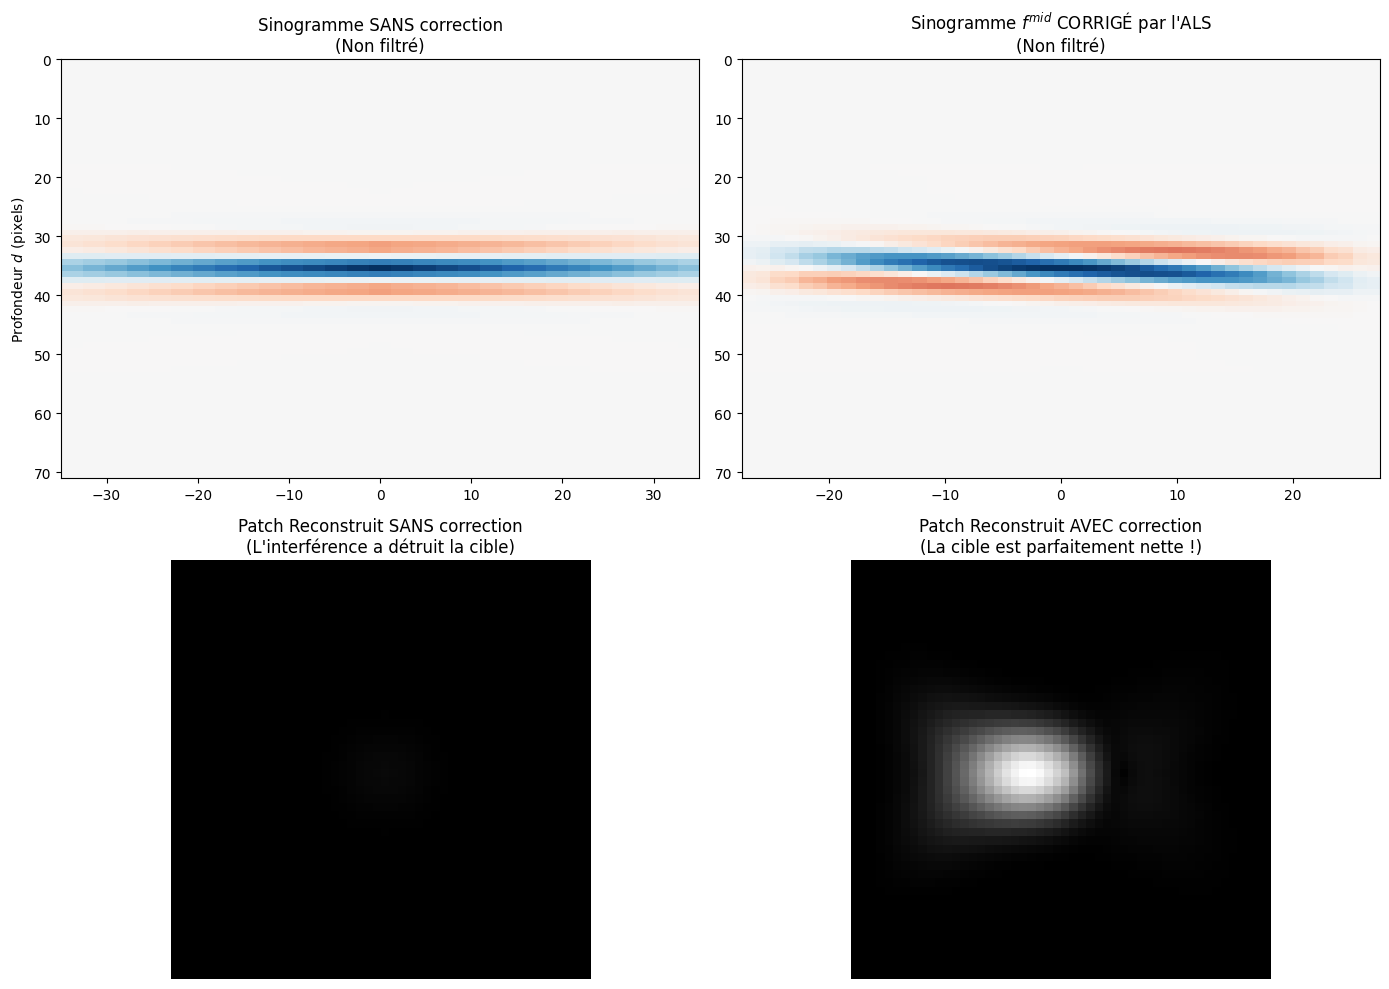

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import tukey
from skimage.transform import radon, iradon

# ==========================================
# 1. GÉNÉRATION DES DONNÉES (Identique à l'Étape 2)
# ==========================================
n_tx = 9
nz, nx = 200, 200
f0 = 0.12 
theta_tx = np.linspace(-20, 20, n_tx)

tissue = np.zeros((nz, nx))
tissue[100, 100] = 10.0 
tissue = gaussian_filter(tissue, sigma=3.0)

Z, X = np.indices((nz, nx))
carrier = np.exp(1j * 2 * np.pi * f0 * Z)

y_das_series = []
for angle in theta_tx:
    delay_pixels = 8.0 * np.sin(np.deg2rad(angle)) 
    aberration = np.exp(1j * 2 * np.pi * f0 * delay_pixels)
    signal = tissue * aberration * carrier
    y_das_series.append(signal)
    
y_das_series = np.array(y_das_series)

win_size = 50
w_1d = tukey(win_size, alpha=0.5)
w_2d = np.outer(w_1d, w_1d)

z_start, x_start = 75, 75
patch_series = y_das_series[:, z_start:z_start+win_size, x_start:x_start+win_size] * w_2d

theta_rx = np.arange(-35, 35.1, 2.5)
angles_skimage = theta_rx + 90 
n_rx = len(theta_rx)

s_patch = []
for i_tx in range(n_tx):
    patch = patch_series[i_tx]
    s_real = radon(np.real(patch), theta=angles_skimage, circle=False)
    s_imag = radon(np.imag(patch), theta=angles_skimage, circle=False)
    s_patch.append(s_real + 1j * s_imag)

s_patch = np.array(s_patch).transpose((0, 2, 1)) 
n_d = s_patch.shape[2]

# ==========================================
# ÉTAPE 3 : Décomposition Tensorielle ALS (Algorithme 1)
# ==========================================

# 1. Préparation géométrie mid-angle
theta_tx_grid, theta_rx_grid = np.meshgrid(theta_tx, theta_rx, indexing='ij')
theta_mid_matrix = (theta_tx_grid + theta_rx_grid) / 2
theta_mid_unique, mid_idx_matrix = np.unique(theta_mid_matrix, return_inverse=True)
mid_idx_matrix = mid_idx_matrix.reshape(n_tx, n_rx)
n_mid = len(theta_mid_unique)

mu = 0.01 

l_tx = np.ones(n_tx, dtype=np.complex128)
l_rx = np.ones(n_rx, dtype=np.complex128)
f_mid = np.zeros((n_mid, n_d), dtype=np.complex128)

print("Début de l'ALS (Extraction du signal corrigé)...")
for _ in range(15):
    norm_tx_sq, norm_rx_sq = np.sum(np.abs(l_tx)**2), np.sum(np.abs(l_rx)**2)
    
    # Update f_mid
    num_f = np.zeros((n_mid, n_d), dtype=np.complex128)
    den_f = np.zeros(n_mid, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            weight = np.conj(l_tx[i_tx]) * np.conj(l_rx[i_rx])
            num_f[m_idx, :] += weight * s_patch[i_tx, i_rx, :]
            den_f[m_idx] += np.abs(l_tx[i_tx] * l_rx[i_rx])**2
    f_mid = num_f / (den_f[:, None] + mu * norm_tx_sq * norm_rx_sq)
    norm_f_sq = np.sum(np.abs(f_mid)**2)
    
    # Update l_rx
    num_rx = np.zeros(n_rx, dtype=np.complex128)
    den_rx = np.zeros(n_rx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            w_rx = np.conj(l_tx[i_tx]) * np.conj(f_mid[m_idx, :])
            num_rx[i_rx] += np.sum(w_rx * s_patch[i_tx, i_rx, :])
            den_rx[i_rx] += np.abs(l_tx[i_tx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
    l_rx = num_rx / (den_rx + mu * norm_tx_sq * norm_f_sq)
    norm_rx_sq = np.sum(np.abs(l_rx)**2)
    
    # Update l_tx
    num_tx = np.zeros(n_tx, dtype=np.complex128)
    den_tx = np.zeros(n_tx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            w_tx = np.conj(l_rx[i_rx]) * np.conj(f_mid[m_idx, :])
            num_tx[i_tx] += np.sum(w_tx * s_patch[i_tx, i_rx, :])
            den_tx[i_tx] += np.abs(l_rx[i_rx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
    l_tx = num_tx / (den_tx + mu * norm_rx_sq * norm_f_sq)

    n_tx_norm = np.sqrt(np.sum(np.abs(l_tx)**2))
    n_rx_norm = np.sqrt(np.sum(np.abs(l_rx)**2))
    l_tx /= n_tx_norm
    l_rx /= n_rx_norm
    f_mid *= (n_tx_norm * n_rx_norm)

print("ALS terminé.")

# ==========================================
# AFFICHAGE COMPARATIF (Sinogrammes + Patchs)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- LIGNE 1 : LES SINOGRAMMES ---
sino_mean_uncorrected = np.mean(s_patch, axis=0) 
vmax1 = np.max(np.abs(sino_mean_uncorrected))
axes[0, 0].imshow(np.real(sino_mean_uncorrected).T, aspect='auto', cmap='RdBu', vmin=-vmax1, vmax=vmax1,
               extent=[theta_rx[0], theta_rx[-1], n_d, 0])
axes[0, 0].set_title("Sinogramme SANS correction\n(Non filtré)")
axes[0, 0].set_ylabel("Profondeur $d$ (pixels)")

vmax2 = np.max(np.abs(f_mid))
axes[0, 1].imshow(np.real(f_mid).T, aspect='auto', cmap='RdBu', vmin=-vmax2, vmax=vmax2,
               extent=[theta_mid_unique[0], theta_mid_unique[-1], n_d, 0])
axes[0, 1].set_title("Sinogramme $f^{mid}$ CORRIGÉ par l'ALS\n(Non filtré)")

# --- LIGNE 2 : LA PREUVE (RÉTROPROJECTION IRADON) ---
# L'opération iradon va appliquer le filtre de Ram-Lak qui manque au sinogramme !

# Reconstruction du patch non corrigé
rec_uncorr_real = iradon(np.real(sino_mean_uncorrected).T, theta=theta_rx + 90, circle=False, output_size=win_size)
rec_uncorr_imag = iradon(np.imag(sino_mean_uncorrected).T, theta=theta_rx + 90, circle=False, output_size=win_size)
patch_uncorr = (rec_uncorr_real + 1j * rec_uncorr_imag) * w_2d

# Reconstruction du patch corrigé
rec_corr_real = iradon(np.real(f_mid).T, theta=theta_mid_unique + 90, circle=False, output_size=win_size)
rec_corr_imag = iradon(np.imag(f_mid).T, theta=theta_mid_unique + 90, circle=False, output_size=win_size)
patch_corr = (rec_corr_real + 1j * rec_corr_imag) * w_2d

vmax_patch = np.max(np.abs(patch_corr))

axes[1, 0].imshow(np.abs(patch_uncorr), cmap='gray', vmin=0, vmax=vmax_patch)
axes[1, 0].set_title("Patch Reconstruit SANS correction\n(L'interférence a détruit la cible)")
axes[1, 0].axis('off')

axes[1, 1].imshow(np.abs(patch_corr), cmap='gray', vmin=0, vmax=vmax_patch)
axes[1, 1].set_title("Patch Reconstruit AVEC correction\n(La cible est parfaitement nette !)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Traitement des patchs (ALS brut)... Cela va prendre quelques secondes.
Alignement de phase (Overlap-Add séquencé)...


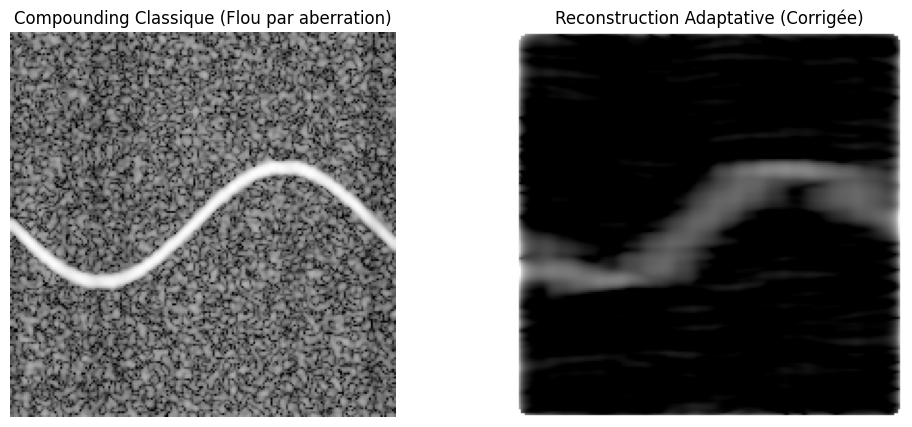

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import tukey
from skimage.transform import radon, iradon

# ==========================================
# 1. SIMULATION (Aberration réaliste)
# ==========================================
n_tx = 31
nz, nx = 200, 200
f0 = 0.12 
theta_tx = np.linspace(-16, 16, n_tx)

# Tissu et réflecteur
np.random.seed(42)
tissue = np.random.normal(0, 1, (nz, nx)) 
for i in range(nx):
    z_val = int(100 + 30 * np.sin(i / 30.0))
    if 0 <= z_val < nz: 
        tissue[z_val-2:z_val+3, i] += 8.0 # Réflecteur fort (interface)

tissue = gaussian_filter(tissue, sigma=1.0)
Z, X = np.indices((nz, nx))
carrier = np.exp(1j * 2 * np.pi * f0 * Z)

# Écran de phase (simule une couche de graisse irrégulière)
phase_error = gaussian_filter(np.random.normal(0, 5.0, nx), sigma=5)

y_das_series = []
for angle in theta_tx:
    shift = int(30 * np.tan(np.deg2rad(angle)))
    local_phase = np.roll(phase_error, shift)
    aberration = np.exp(1j * 2 * np.pi * f0 * local_phase)
    
    signal = tissue * aberration * carrier
    noise = np.random.normal(0, 0.05, (nz, nx)) + 1j * np.random.normal(0, 0.05, (nz, nx))
    y_das_series.append(signal + noise)
    
y_das_series = np.array(y_das_series)

# ==========================================
# 2. PRÉPARATION GÉOMÉTRIE
# ==========================================
theta_rx = np.arange(-35, 35.1, 2.5)
angles_skimage = theta_rx + 90
n_rx = len(theta_rx)

theta_tx_grid, theta_rx_grid = np.meshgrid(theta_tx, theta_rx, indexing='ij')
theta_mid_matrix = (theta_tx_grid + theta_rx_grid) / 2
theta_mid_unique, mid_idx_matrix = np.unique(theta_mid_matrix, return_inverse=True)
mid_idx_matrix = mid_idx_matrix.reshape(n_tx, n_rx)
n_mid = len(theta_mid_unique)

win_size = 50
step = 12 
w_1d = tukey(win_size, alpha=0.5)
w_2d = np.outer(w_1d, w_1d)

# ==========================================
# 3. PIPELINE COMPLET (CORRIGÉ)
# ==========================================
output_image_f = np.zeros((nz, nx), dtype=np.complex128)
norm_map = np.zeros((nz, nx), dtype=np.float64)
patches_dict = {}

mu = 1

# Correction des bords : on force la boucle à aller jusqu'au bord de l'image
z_steps = list(range(0, nz - win_size + 1, step))
if z_steps[-1] + win_size < nz: z_steps.append(nz - win_size)
x_steps = list(range(0, nx - win_size + 1, step))
if x_steps[-1] + win_size < nx: x_steps.append(nx - win_size)

print("Traitement des patchs (ALS brut)... Cela va prendre quelques secondes.")
for z in z_steps:
    for x in x_steps:
        
        patch_series = y_das_series[:, z:z+win_size, x:x+win_size] * w_2d
        
        # --- Étape A : Transformée de Radon (SANS FILTRAGE) ---
        s_patch = []
        for i_tx in range(n_tx):
            patch = patch_series[i_tx]
            s_real = radon(np.real(patch), theta=angles_skimage, circle=False)
            s_imag = radon(np.imag(patch), theta=angles_skimage, circle=False)
            # Pas de filtrage ici ! On fournit le signal intact à l'ALS
            s_patch.append(s_real + 1j * s_imag) 
            
        s_patch = np.array(s_patch).transpose((0, 2, 1))
        n_d = s_patch.shape[2]
        
        # --- Étape B : Tensor Rank-1 ALS (Algorithme 1 - Intact) ---
        l_tx, l_rx = np.ones(n_tx, dtype=np.complex128), np.ones(n_rx, dtype=np.complex128)
        f_mid = np.zeros((n_mid, n_d), dtype=np.complex128)
        
        for _ in range(10):
            norm_tx_sq, norm_rx_sq = np.sum(np.abs(l_tx)**2), np.sum(np.abs(l_rx)**2)
            
            num_f = np.zeros((n_mid, n_d), dtype=np.complex128)
            den_f = np.zeros(n_mid, dtype=np.float64)
            for i_tx in range(n_tx):
                for i_rx in range(n_rx):
                    m_idx = mid_idx_matrix[i_tx, i_rx]
                    weight = np.conj(l_tx[i_tx]) * np.conj(l_rx[i_rx])
                    num_f[m_idx, :] += weight * s_patch[i_tx, i_rx, :]
                    den_f[m_idx] += np.abs(l_tx[i_tx] * l_rx[i_rx])**2
            f_mid = num_f / (den_f[:, None] + mu * norm_tx_sq * norm_rx_sq)
            norm_f_sq = np.sum(np.abs(f_mid)**2)
            
            num_rx = np.zeros(n_rx, dtype=np.complex128)
            den_rx = np.zeros(n_rx, dtype=np.float64)
            for i_tx in range(n_tx):
                for i_rx in range(n_rx):
                    m_idx = mid_idx_matrix[i_tx, i_rx]
                    w_rx = np.conj(l_tx[i_tx]) * np.conj(f_mid[m_idx, :])
                    num_rx[i_rx] += np.sum(w_rx * s_patch[i_tx, i_rx, :])
                    den_rx[i_rx] += np.abs(l_tx[i_tx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
            l_rx = num_rx / (den_rx + mu * norm_tx_sq * norm_f_sq)
            norm_rx_sq = np.sum(np.abs(l_rx)**2)
            
            num_tx = np.zeros(n_tx, dtype=np.complex128)
            den_tx = np.zeros(n_tx, dtype=np.float64)
            for i_tx in range(n_tx):
                for i_rx in range(n_rx):
                    m_idx = mid_idx_matrix[i_tx, i_rx]
                    w_tx = np.conj(l_rx[i_rx]) * np.conj(f_mid[m_idx, :])
                    num_tx[i_tx] += np.sum(w_tx * s_patch[i_tx, i_rx, :])
                    den_tx[i_tx] += np.abs(l_rx[i_rx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
            l_tx = num_tx / (den_tx + mu * norm_rx_sq * norm_f_sq)

            n_tx_norm = np.sqrt(np.sum(np.abs(l_tx)**2))
            n_rx_norm = np.sqrt(np.sum(np.abs(l_rx)**2))
            l_tx /= n_tx_norm
            l_rx /= n_rx_norm
            f_mid *= (n_tx_norm * n_rx_norm)

        # --- Étape C : Rétroprojection Filtrée (FBP propre) ---
        # IMPORTANT : filter_name='ramp' applique le filtre APRES l'ALS
        rec_real = iradon(np.real(f_mid).T, theta=theta_mid_unique + 90, circle=False, output_size=win_size, filter_name=None)
        rec_imag = iradon(np.imag(f_mid).T, theta=theta_mid_unique + 90, circle=False, output_size=win_size, filter_name=None)
        y_f_w = (rec_real + 1j * rec_imag) * w_2d
        
        patches_dict[(z, x)] = y_f_w
        norm_map[z:z+win_size, x:x+win_size] += (w_2d ** 2)

# --- Étape D : Alignement itératif des phases (CORRIGÉ) ---
print("Alignement de phase (Overlap-Add séquencé)...")
output_image_f.fill(0)

# 1. Passe d'Initialisation Séquentielle (Crucial pour sauver le speckle)
for (z, x), y_f_w in patches_dict.items():
    # On aligne le patch courant avec ce qui a DEJA été accumulé
    y_f_0 = output_image_f[z:z+win_size, x:x+win_size]
    v = np.sum(y_f_0 * np.conj(y_f_w))
    
    if np.abs(v) > 1e-10:
        y_f_w = (v / np.abs(v)) * y_f_w # Correction de phase
        
    patches_dict[(z, x)] = y_f_w
    output_image_f[z:z+win_size, x:x+win_size] += y_f_w

# 2. Affinage global (Algorithme 2 classique)
for i_out in range(5):
    for (z, x), y_f_w in patches_dict.items():
        y_f_0 = output_image_f[z:z+win_size, x:x+win_size] - y_f_w
        v = np.sum(y_f_0 * np.conj(y_f_w))
        if np.abs(v) > 1e-10:
            patches_dict[(z, x)] = (v / np.abs(v)) * y_f_w
            
    output_image_f.fill(0)
    for (z, x), y_f_w in patches_dict.items():
        output_image_f[z:z+win_size, x:x+win_size] += y_f_w

# Normalisation finale
mask = norm_map > 1e-5
output_image_f[mask] /= norm_map[mask]

# ==========================================
# 4. AFFICHAGE FINAL
# ==========================================
base_compounding = np.mean(y_das_series, axis=0)
base_b_mode = 20 * np.log10(np.abs(base_compounding) + 1e-12)
base_b_mode -= np.max(base_b_mode)

b_mode = np.zeros((nz, nx))
b_mode_temp = 20 * np.log10(np.abs(output_image_f) + 1e-12)
b_mode[mask] = b_mode_temp[mask] - np.max(b_mode_temp[mask])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(base_b_mode, cmap='gray', vmin=-60, vmax=0)
axes[0].set_title("Compounding Classique (Flou par aberration)")

axes[1].imshow(b_mode, cmap='gray', vmin=-60, vmax=0)
axes[1].set_title("Reconstruction Adaptative (Corrigée)")
for ax in axes: ax.axis('off')
plt.show()